# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Evan Wu

**ID**: 5839048

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\evan\Documents\GitHub\hw2-etw`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

Atmospheric CO<sub>2</sub>:
- Increased atmospheric CO<sub>2</sub> concentrations results in increased global mean temperature
- Can be decreased by the ocean absorbing CO<sub>2</sub>

Ocean CO<sub>2</sub>:
- Increased by taking CO<sub>2</sub> from the atmosphere
- Can be decreased by higher global temperatures as it can be harder to absorb CO<sub>2</sub>

Global mean temperature:
- Increased by larger atmospheric CO<sub>2</sub> concentrations


### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

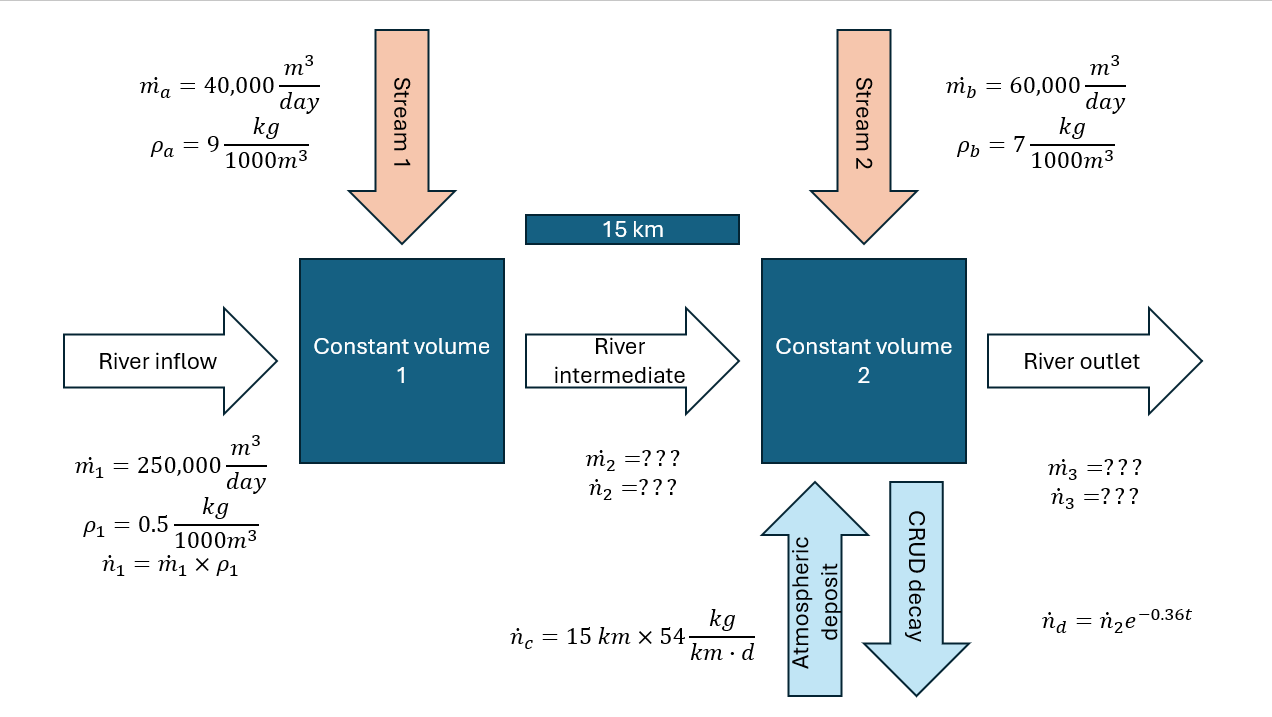

This diagram is built on the following assumptions:
- Box/Control Volume 1 occurs when the river and Stream 1 immediately mix
- System is in steady state
- No additional accumulation/consumption besides CRUD decay along the river and CRUD deposited by the atmosphere

It was decided to include two boxes for control volumes in this system diagram. The first box is for when the river and Stream 1 mix. The second box is to account for not only the mixing of the river intermediate stream and Stream 2, but also any CRUD added by the atmosphere or decayed along the river. The sum of CRUD added along the river can be simplified as an in-flow into Box 2, and the total of CRUD lost to exponential decay can be summarized as a single value exiting Box 2.   

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.


> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

Known:
- River flow velocity: $10 \frac{km}{d}$
- CRUD exponential decay along the river: $\frac{0.36}{d}$
- CRUD deposited by atmosphere: $54 \frac{kg}{km \bullet d}$
- River volumetric flow rate: $250,000 \frac{m^3}{d}$
- River CRUD density: $ 0.5 \frac{kg}{1000 m^3}$
- Distance from Stream 1 to Stream 2: $ 15km$
- Stream 1 incoming volumetric flow rate (Stream closer to river inflow): $40,000 \frac{m^3}{d}$
- Stream 1 CRUD density: $9 \frac{kg}{1000m^3}$
- Stream 2 incoming volumetric flow rate (Stream further from river inflow): $60,000 \frac{m^3}{d}$
- Stream 2 CRUD density: $7 \frac{kg}{1000m^3}$

From the system diagram, we can consider the two boxes separately before combining them into one general equation

$$ Inlet - Outlet - Consumption + Generation = Accumulation $$

For Box 1:
- There is no consumption or generation of CRUD
- No accumulation
- River and Stream 1 mix immediately

$$ Inlet - Outlet = 0 $$
$$ Inlet = Outlet $$

Inlet streams:
- River CRUD flow rate: $ 250,000 \frac{m^3}{d} \times 0.5 \frac{kg}{1000m^3} = 1250 \frac{kg}{d}$
- Stream 1 CRUD flow rate: $ 40,000 \frac{m^3}{d} \times 9 \frac{kg}{1000m^3} = 360 \frac{kg}{d} $

Outlet:
- River intermediate CRUD flowrate: $ 1250 + 360 \frac{kg}{d} = 1610 \frac{kg}{d} \div 10 \frac{km}{d} = 161 \frac{kg}{km}$

For Box 2:
- There is no accumulation
- River intermediate and Stream 2 mix after 15km down the river
- Consumption and generation of CRUD takes place in Stream 2 

$$ Inlet - Outlet - Consumption + Generation = Accumulation $$
$$ Inlet - Outlet - Consumption + Generation = 0 $$

Inlet streams:
- River intermediate CRUD flow rate: $ 161 \frac{kg}{km}$
- Stream 2 CRUD flow rate: $ 60,000 \frac{m^3}{d} \times 7 \frac{kg}{1000m^3} = 420 \frac{kg}{d} \div 10 \frac{km}{d} = 42 \frac{kg}{km}$

Generation:
- Atmospheric deposit: $ 54 \frac{kg}{km \bullet d} \times 15 km \div 10 \frac{km}{d} = 81 \frac{kg}{km}$

Consumption:
- CRUD exponential decay: $ 161 

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

<span id="eq-climate">$$
{C\frac{dT}{dt}} = {\frac{(1-\alpha)S}{4}} - {(A - BT)}$$</span>

Divide both sides by C:

<span id="eq-climate">$$
{\frac{dT}{dt}} = \frac{1}{C}({\frac{(1-\alpha)S}{4}} - {(A - BT)})$$</span>

Provided that $ \frac{dT}{dt} \approx \frac{T(t+\triangle t - T(t))}{\triangle t} $:

<span id="eq-climate">$$
{\frac{T(t + \triangle t) - T(t)}{\triangle t}} = \frac{1}{C}({\frac{(1-\alpha)S}{4}} - {(A - BT(t))})$$</span>

Rearrange to make $ T(t + \triangle t)$ the subject:

<span id="eq-climate">$$
T(t + \triangle t) - T(t) = \frac{\triangle t}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + \triangle t) = T(t) + \frac{\triangle t}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

Let $\triangle t = 1$ year

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-\alpha)S}{4}} - A + BT(t))$$</span>

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

Have to consider three scenarios for the climate model based on the conditions where albedo is different. 

For $ T\leq -10^oC $:

$\alpha (T) = \alpha_i = 0.5$

Simple climate model from $ -60^oC \leq T \leq -10^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-0.5)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{0.5S}{4}} - A + BT(t))$$</span>

For $ T\geq 10^oC $:

$\alpha (T) = \alpha_0 = 0.3$

Simple climate model from $ 10^oC \leq T \leq 30^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-0.3)S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{0.7S}{4}} - A + BT(t))$$</span>

For $ -10^oC \leq T\leq 10^oC $:

$\alpha (T) = \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20)$

For $\alpha_i = 0.5, \alpha_0 = 0.3$:

$\alpha (T) = 0.5 + (0.3 - 0.5)((T+10) / 20)$

$\alpha (T) = 0.5 - 0.01(T+10) = 0.4 - 0.01T$

Simple climate model from $ -10^oC \leq T \leq 10^oC$:

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(1-(0.4 - 0.01T))S}{4}} - A + BT(t))$$</span>

<span id="eq-climate">$$
T(t + 1) = T(t) + \frac{1}{C}({\frac{(0.6 + 0.01T(t))S}{4}} - A + BT(t))$$</span>

Now that there are mathematical equations for what the differential equation would look under different temperatures, two functions can be created to calculate the value of the equation's time step and $T(t+1)$. The simulate_timestep function is coded to use different albedo values depending on the current temperature of the system. The simulate_climate function creates an empty array of temperature values to be stored later and runs a for loop to create future T values based on the current temperature and the provided constants. The loop is ran for as many times as the total duration divided by $\Delta t$.

In scenarios where T = $10^o C$ or $-10^o C$, the equation where albedo is dependent on temperature would be given priority over the static albedo values. While this is a small nitpick, it may have effects on the system as a whole.

In [ ]:
function simulate_timestep(T, B, C, alpha, S, A)
    if T <= -10 && T >= 10
        alpha = 0.4 - 0.01 * T
    elseif T > 10
        alpha = 0.3
    else
        alpha = 0.5
    end
    return (S * (1 - alpha) / 4 - A + B * T) / C
end

function simulate_climate(T0, B, C, alpha, S, A, time, dt)
    steps = Int64(time / dt)
    T = zeros(steps + 1)
    T[1] = T0    
    for i in 1:steps
        T[i+1] = T[i] + simulate_timestep(T[i], B, C, alpha, S, A) * dt
    end
    return T
end

1.0

The numerical constants in the equation can be plugged into the two functions. A range for the different temperatures sampled is created. The step increase for each temperature is selected to be +5 as it provides sufficient samples to witness how varying albedo affects global temperature over time. An empty array called real_dataset is generated to store future temperature values. 

To trial each temperature value, a for loop is used to model the differential equation based on the initial temperature and numerical constants. In the loop, there is a check to determine which albedo value is used according to the initial temperature. 

Any[[-60.0, -59.69019607843137, -59.38828911956939, -59.09407782828625, -58.80736604050641, -58.52796259241507, -58.25568119300057, -57.990340299845656, -57.73176299808488, -57.479776882447425, -57.23421394230661, -56.99491044965958, -56.76170684996237, -56.53444765574765, -56.31298134295408, -56.09716024989839, -55.88684047882255, -55.6818817999506, -55.48214755799108, -55.287504581022674, -55.09782309170249, -54.912976620737524, -54.73284192256186, -54.55729889316322, -54.38623049000416, -54.21952265398445, -54.05706423339269, -53.8987469097964, -53.7444651258212, -53.594116014770854, -53.4475993320414, -53.30481738828348, -53.16567498426841, -53.030079347414514, -52.8979400699314, -52.769169048540995, -52.64368042573505, -52.521390532530035, -52.40221783268123, -52.286082868318765, -52.17290820696946, -52.062618389929064, -51.95513988195048, -51.850401022214484, -51.74833197655019, -51.648864690873424, -51.55193284581195, -51.45747181248733, -51.36541860942393, -51.27571186055626, -

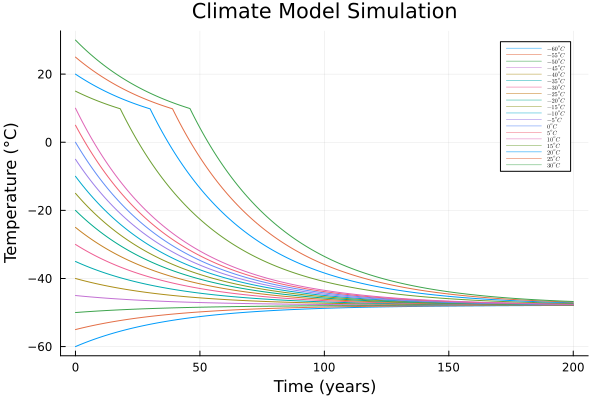

In [31]:
# Constants
B = -1.3 # W/m^2/°C
C = 51 # J / m^2 / °C
S  = 1272 # W/m^2 (solar constant during Neoprotereozoic era) 
A = 221.2 # W/m^2
time = 200.0 # years
dt = 1.0 # years

temperature_range = [-60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30];
real_dataset = [];

for T in temperature_range
    if T <= -10
        alpha = 0.5
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    elseif T > -10 && T < 10
        alpha = 0.4 - 0.01 * T
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    else
        alpha = 0.3
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset, final_data)
    end
end

print(real_dataset)

plot(0:dt:time, real_dataset, xlabel="Time (years)", ylabel="Temperature (°C)", title="Climate Model Simulation",
label = [L"$-60^o C$" L"$-55^o C$" L"$-50^o C$" L"$-45^o C$" L"$-40^o C$" L"$-35^o C$" L"$-30^o C$" L"$-25^o C$" L"$-20^o C$" L"$-15^o C$" L"$-10^o C$" L"$-5^o C$" L"$0^o C$" L"$5^o C$" L"$10^o C$" L"$15^o C$" L"$20^o C$" L"$25^o C$" L"$30^o C$"
], legend=:best, legendfontsize=4)

Caption: Climate model simulation for Earth's global temperature change over 200 years with starting temperatures from $[-60^oC, 30^oC]$. 

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

Any[[-60.0, -59.47205882352941, -58.95757497116493, -58.45620541307641, -57.967615863331325, -57.491480557011116, -57.02748203300887, -56.57531092236355, -56.13466574198958, -55.705252693664356, -55.28678546813958, -54.878985054245824, -54.48157955286309, -54.09430399563325, -53.71690016829358, -53.34911643851355, -52.99070758812007, -52.64143464959936, -52.301064746766436, -51.96937093949592, -51.64613207241073, -51.33113262742771, -51.02416258006191, -50.72501725939367, -50.4334972116052, -50.149408066995655, -49.87256041038596, -49.6027696548271, -49.33985591852758, -49.083643904918056, -48.83396278577308, -48.5906460873122, -48.353531579204244, -48.122461166400996, -47.89728078372803, -47.67784029316241, -47.46399338372886, -47.25559747394754, -47.052513616768486, -46.85460640692929, -46.66174389067423, -46.47379747777469, -46.290641855792195, -46.112154906526904, -45.93821762459582, -45.768714038086515, -45.60353113123333, -45.44255876906464, -45.28568962397083, -45.13281910414412

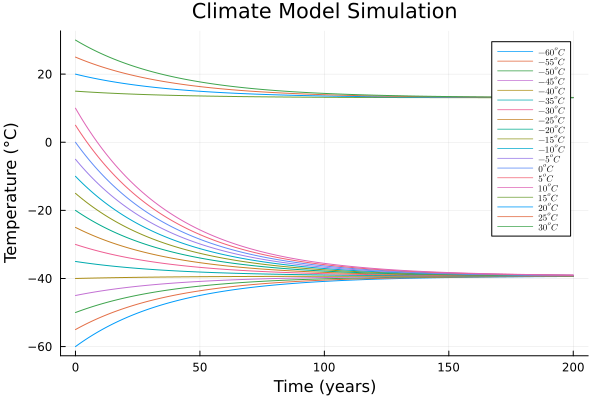

In [33]:
temperature_range = [-60, -55, -50, -45, -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30];
real_dataset2 = [];

S = 1361 # W/m^2 (current solar constant)

for T in temperature_range
    if T <= -10
        alpha = 0.5
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    elseif T > -10 && T < 10
        alpha = 0.4 - 0.01 * T
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    else
        alpha = 0.3
        final_data = simulate_climate(T, B, C, alpha, S, A, time, dt)
        push!(real_dataset2, final_data)
    end
end

print(real_dataset2)

plot(0:dt:time, real_dataset2, xlabel="Time (years)", ylabel="Temperature (°C)", title="Climate Model Simulation",
label = [L"$-60^o C$" L"$-55^o C$" L"$-50^o C$" L"$-45^o C$" L"$-40^o C$" L"$-35^o C$" L"$-30^o C$" L"$-25^o C$" L"$-20^o C$" L"$-15^o C$" L"$-10^o C$" L"$-5^o C$" L"$0^o C$" L"$5^o C$" L"$10^o C$" L"$15^o C$" L"$20^o C$" L"$25^o C$" L"$30^o C$"
], legend=:best, legendfontsize=6) 

## References

List any external references consulted, including classmates.